# EDA WhoOwns

## Daten laden und vorbereiten

Diese Zelle lädt alle relevanten Datensätze für die EDA und definiert die Pfade aus dem Projektordner.

Im Code werden:
- die Quellen für Wohneigentum, Bewohnertyp, Wohnfläche und demografische Bilanz eingelesen,
- zusätzliche Jahresangaben für BFS-Daten gesetzt,
- und die eingelesenen Datenstrukturen kurz geprüft (Shape-Ausgabe).

In [226]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Project root with data/ folder not found.')

BASE_PATH = find_project_root(Path.cwd())

# Definiere alle Datenpfade
WHONEIGENTUMSQUOTE_PROCESSED_PATH = BASE_PATH / 'data' / 'whoOwns' / 'processed' / 'wohneigentumsquote_kanton_2026_clean.csv'
WOHNFLAECHE_PROCESSED_PATH = BASE_PATH / 'data' / 'whoOwns' / 'processed' / 'bfs_wohnflaeche_20260414_clean.csv'
BEWOHNERTYP_PROCESSED_PATH = BASE_PATH / 'data' / 'whoOwns' / 'processed' / 'bfs_bewohnertyp_20260414_clean.csv'
WHOOWNS_META_RAW_PATH = BASE_PATH / 'data' / 'whoOwns' / 'raw' / 'metadaten_wohneigentumsquote_kanton_2026.ods'
DEMOGRAFISCHE_BILANZ_PATH = BASE_PATH / 'data' / 'demografischeBilanz.csv'

# Lade Datenquellen
print("📊 Lade Datenquellen...")
wohneigentum = pd.read_csv(WHONEIGENTUMSQUOTE_PROCESSED_PATH)
wohnflaeche = pd.read_csv(WOHNFLAECHE_PROCESSED_PATH)
bewohnertyp = pd.read_csv(BEWOHNERTYP_PROCESSED_PATH)

demografische_bilanz = pd.read_csv(DEMOGRAFISCHE_BILANZ_PATH, sep=';', encoding='latin1')

# Füge Jahr-Spalte zu (noch als kontant, da alle Daten für 2024 sind)
wohnflaeche['time_period'] = 2024
bewohnertyp['time_period'] = 2024

print(f"✓ Wohneigentumsquote: {wohneigentum.shape}")
print(f"✓ Wohnflächenverteilung: {wohnflaeche.shape}")
print(f"✓ Bewohnertypen: {bewohnertyp.shape}")
print(f"✓ Demografische Bilanz: {demografische_bilanz.shape}")

📊 Lade Datenquellen...
✓ Wohneigentumsquote: (162, 10)
✓ Wohnflächenverteilung: (100, 4)
✓ Bewohnertypen: (340, 9)
✓ Demografische Bilanz: (154224, 7)


## Generationen und Analysebasis erzeugen

Diese Zelle erstellt die zentrale analytische Grundlage für alle Folgegrafiken.

Im Code werden:
- Altersangaben in numerische Form gebracht,
- Geburtsjahre und Generationenlabels berechnet,
- sowie harmonisierte Spalten für Demografie, Bewohnertyp und Wohnfläche aufgebaut.

In [227]:
# Generations-Labels und Hypothesen für die erklärende Analyse
# Hypothese 1: Ältere Generationen machen einen grösseren Anteil an Eigentum und Wohnraum aus.
# Hypothese 2: Eigentumsquote, Altersstruktur und Wohnfläche hängen auf Kantonsebene zusammen.
# Hypothese 3: Bewohnertypen unterscheiden sich sichtbar nach Generation und Jahr.


def generation_from_birth_year(birth_year: float) -> str:
    if pd.isna(birth_year):
        return 'Ausserhalb Definition'
    if birth_year <= 1945:
        return 'Silent Generation (<=1945)'
    if 1946 <= birth_year <= 1964:
        return 'Babyboomers (1946-1964)'
    if 1965 <= birth_year <= 1980:
        return 'Generation X (1965-1980)'
    if 1981 <= birth_year <= 1996:
        return 'Millennials / Gen Y (1981-1996)'
    if 1997 <= birth_year <= 2012:
        return 'Generation Z (1997-2012)'
    return 'Ausserhalb Definition'


gen_order = [
    'Silent Generation (<=1945)',
    'Babyboomers (1946-1964)',
    'Generation X (1965-1980)',
    'Millennials / Gen Y (1981-1996)',
    'Generation Z (1997-2012)',
    'Ausserhalb Definition',
]


def find_col(df, keywords):
    keywords = [kw.lower() for kw in keywords]
    for col in df.columns:
        col_lower = str(col).lower()
        if all(kw in col_lower for kw in keywords):
            return col
    return None


# -----------------------------
# 1) Demografische Bilanz
# -----------------------------
demo = demografische_bilanz.copy()
demo.columns = demo.columns.str.strip()

year_col = next((c for c in demo.columns if 'jahr' in c.lower()), None)
canton_col = next((c for c in demo.columns if 'kanton' in c.lower()), None)
age_col = next((c for c in demo.columns if 'alter' in c.lower()), None)
nat_col = next((c for c in demo.columns if 'staatsange' in c.lower()), None)
gender_col = next((c for c in demo.columns if 'geschlecht' in c.lower()), None)
pop_col = next((c for c in demo.columns if '31' in c.lower() and 'dez' in c.lower()), None)

required_cols = [year_col, canton_col, age_col, pop_col]
if any(c is None for c in required_cols):
    missing = [name for name, col in [('Jahr', year_col), ('Kanton', canton_col), ('Alter', age_col), ('Bestand am 31. Dezember', pop_col)] if col is None]
    raise ValueError(f"Fehlende Spalten in demografische_bilanz: {missing}")

if nat_col is not None:
    demo = demo[demo[nat_col].astype(str).str.contains('total', case=False, na=False)].copy()
if gender_col is not None:
    demo = demo[demo[gender_col].astype(str).str.contains('total', case=False, na=False)].copy()

demo['year'] = pd.to_numeric(demo[year_col], errors='coerce')
demo['population'] = pd.to_numeric(demo[pop_col], errors='coerce')
demo['age_num'] = pd.to_numeric(demo[age_col].astype(str).str.extract(r'(\d+)', expand=False), errors='coerce')
demo = demo[demo['year'].notna() & demo['age_num'].notna() & demo['population'].notna()].copy()
demo['year'] = demo['year'].astype(int)
demo['birth_year'] = demo['year'] - demo['age_num']
demo['generation_label'] = demo['birth_year'].apply(generation_from_birth_year)
demo['generation_label'] = pd.Categorical(demo['generation_label'], categories=gen_order, ordered=True)
demo['is_65_plus'] = demo['age_num'] >= 65

demografische_gen = demo.copy()

# -----------------------------
# 2) Bewohnertyp (hat Alter)
# -----------------------------
bewohnertyp_age_col = next((c for c in bewohnertyp.columns if 'alter' in c.lower()), None)
if bewohnertyp_age_col is not None:
    bewohnertyp['age_num'] = pd.to_numeric(bewohnertyp[bewohnertyp_age_col], errors='coerce')
    bewohnertyp['birth_year'] = 2026 - bewohnertyp['age_num']
    bewohnertyp['generation_label'] = bewohnertyp['birth_year'].apply(generation_from_birth_year)
    bewohnertyp['generation_label'] = pd.Categorical(bewohnertyp['generation_label'], categories=gen_order, ordered=True)

# -----------------------------
# 3) Wohnfläche (hat Alter)
# -----------------------------
wohnflaeche_age_col = next((c for c in wohnflaeche.columns if 'alter' in c.lower()), None)
if wohnflaeche_age_col is not None:
    wohnflaeche['age_num'] = pd.to_numeric(wohnflaeche[wohnflaeche_age_col], errors='coerce')
    wohnflaeche['birth_year'] = 2026 - wohnflaeche['age_num']
    wohnflaeche['generation_label'] = wohnflaeche['birth_year'].apply(generation_from_birth_year)
    wohnflaeche['generation_label'] = pd.Categorical(wohnflaeche['generation_label'], categories=gen_order, ordered=True)

print(f"✓ Demografische Daten aufbereitet: {demografische_gen.shape}")
print(f"✓ Demografische Generationen: {demografische_gen['generation_label'].value_counts(dropna=False).to_dict()}")
if 'generation_label' in bewohnertyp.columns:
    print(f"✓ Bewohnertyp Generationen: {bewohnertyp['generation_label'].value_counts(dropna=False).to_dict()}")
if 'generation_label' in wohnflaeche.columns:
    print(f"✓ Wohnfläche Generationen: {wohnflaeche['generation_label'].value_counts(dropna=False).to_dict()}" )

✓ Demografische Daten aufbereitet: (16800, 13)
✓ Demografische Generationen: {'Silent Generation (<=1945)': 3948, 'Babyboomers (1946-1964)': 3192, 'Generation X (1965-1980)': 2688, 'Millennials / Gen Y (1981-1996)': 2688, 'Generation Z (1997-2012)': 2688, 'Ausserhalb Definition': 1596}
✓ Bewohnertyp Generationen: {'Silent Generation (<=1945)': 76, 'Babyboomers (1946-1964)': 76, 'Generation X (1965-1980)': 64, 'Millennials / Gen Y (1981-1996)': 64, 'Generation Z (1997-2012)': 60, 'Ausserhalb Definition': 0}
✓ Wohnfläche Generationen: {'Silent Generation (<=1945)': 19, 'Babyboomers (1946-1964)': 19, 'Generation X (1965-1980)': 16, 'Millennials / Gen Y (1981-1996)': 16, 'Generation Z (1997-2012)': 16, 'Ausserhalb Definition': 14}


## Schweiz: Generationenanteile pro Jahr

Diese Grafik zeigt pro Jahr die Verteilung der Bevölkerung über Generationen als Prozentanteile.

Der Code aggregiert die Schweizer Demografie je Jahr und Generation und zeichnet danach für jedes Jahr einen separaten Balkenplot mit identischer Achsenskalierung.


DEMOGRAFISCHE BILANZ: SCHWEIZ NACH GENERATION (PRO JAHR)


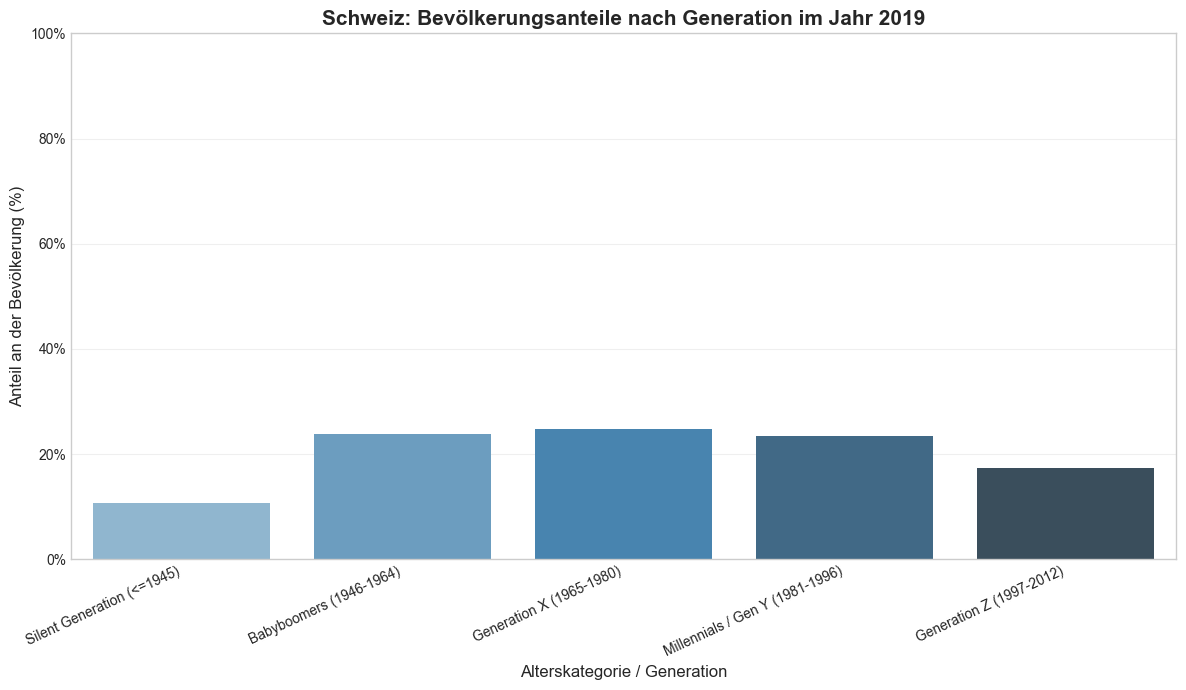

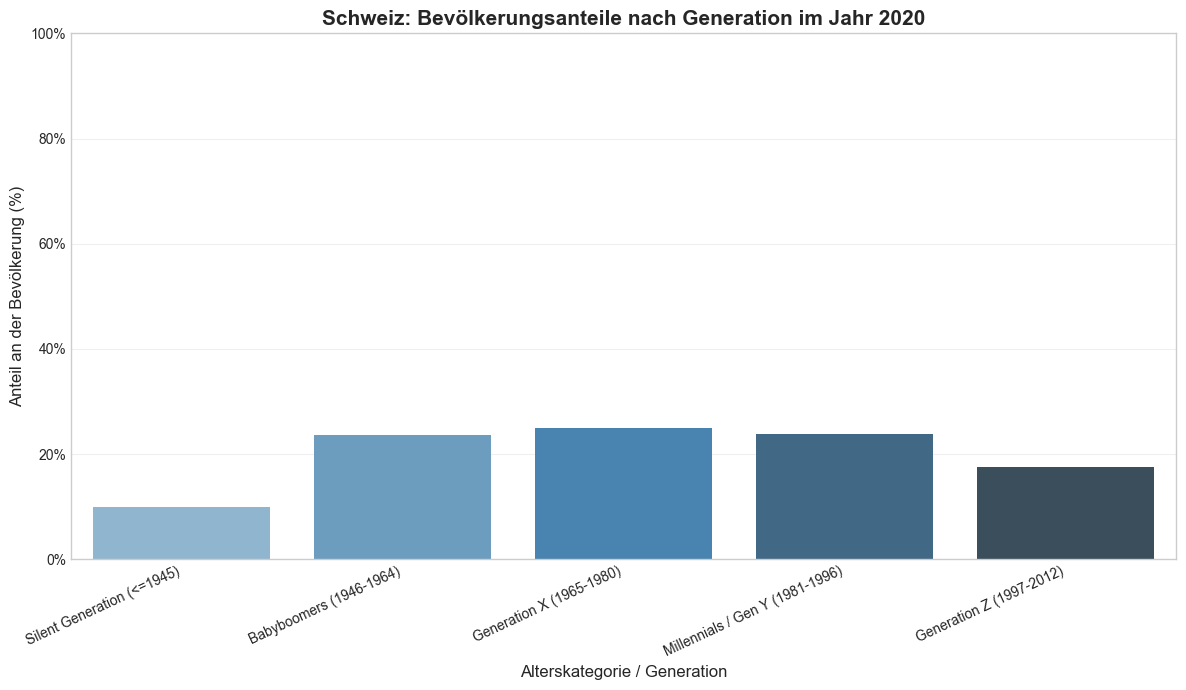

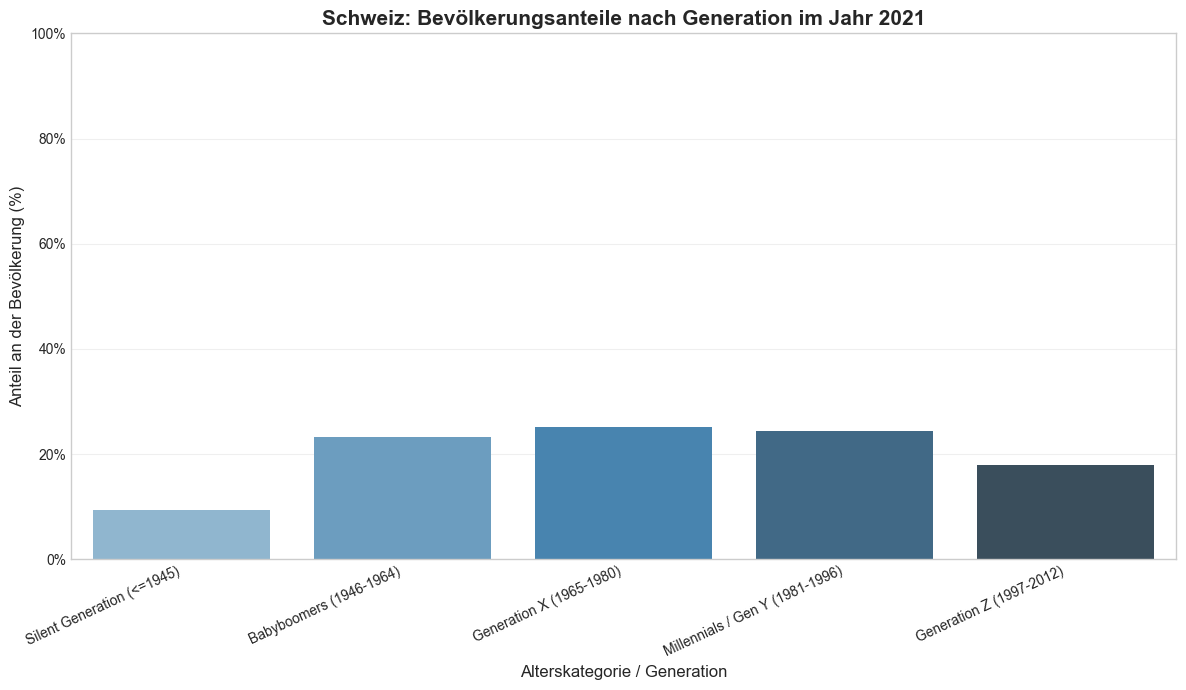

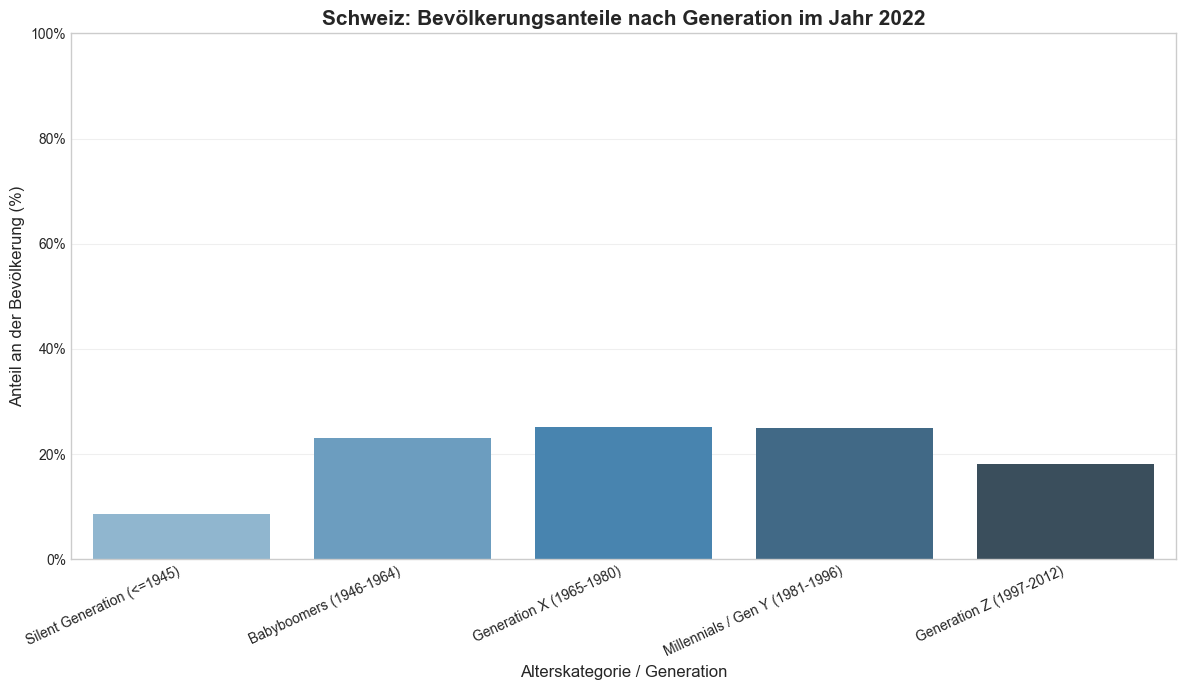

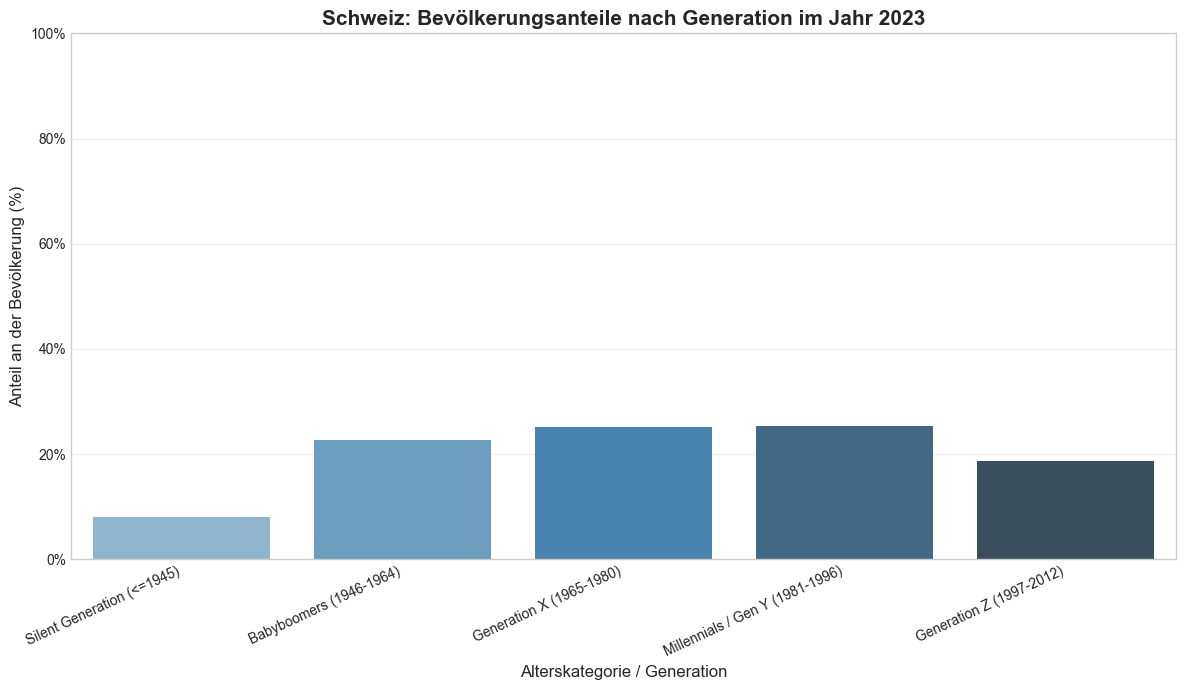

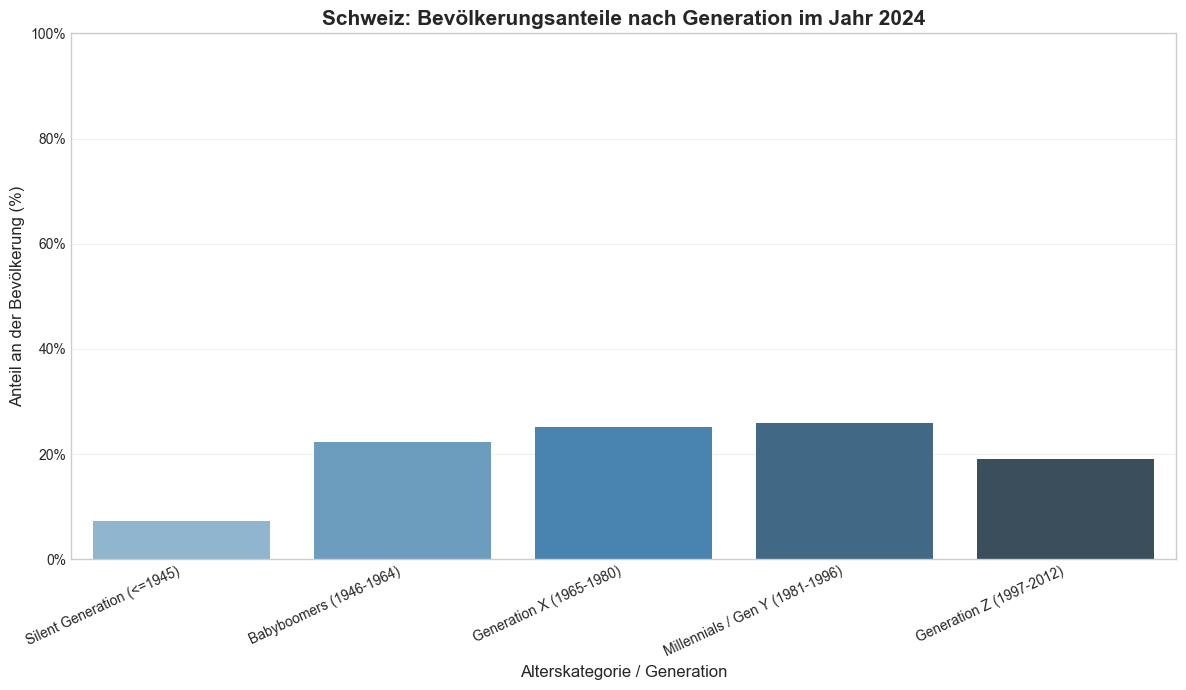

✓ Jahre dargestellt: 6
✓ Schweiz/Jahr-Kombinationen: 30


In [228]:
# Demografische Bilanz: Schweiz pro Generation und Jahr
# Fragestellung: Wie verändert sich die Altersstruktur der Schweiz über die Zeit?
# Hypothese: Jüngere Generationen gewinnen gegenüber älteren Gruppen an Anteil.
print("\n" + "="*70)
print("DEMOGRAFISCHE BILANZ: SCHWEIZ NACH GENERATION (PRO JAHR)")
print("="*70)

schweiz = demografische_gen[
    demografische_gen[canton_col].astype(str).str.strip().str.lower() == 'schweiz'
].copy()
schweiz = schweiz[schweiz['generation_label'] != 'Ausserhalb Definition'].copy()

schweiz_gen_year = (
    schweiz.groupby(['year', 'generation_label'], as_index=False, observed=True)['population']
    .sum()
)

gen_order = [
    'Silent Generation (<=1945)',
    'Babyboomers (1946-1964)',
    'Generation X (1965-1980)',
    'Millennials / Gen Y (1981-1996)',
    'Generation Z (1997-2012)',
]
schweiz_gen_year['generation_label'] = pd.Categorical(
    schweiz_gen_year['generation_label'],
    categories=gen_order,
    ordered=True,
)
schweiz_gen_year['share_pct'] = schweiz_gen_year.groupby('year')['population'].transform(lambda s: s / s.sum() * 100)

all_years = sorted(schweiz_gen_year['year'].dropna().unique().tolist())
y_max = 100

for yr in all_years:
    year_data = (
        schweiz_gen_year[schweiz_gen_year['year'] == yr]
        .sort_values('generation_label')
        .copy()
    )

    plt.figure(figsize=(12, 7))
    ax = sns.barplot(
        data=year_data,
        x='generation_label',
        y='share_pct',
        palette='Blues_d'
    )

    ax.set_title(f'Schweiz: Bevölkerungsanteile nach Generation im Jahr {yr}', fontsize=15, fontweight='bold')
    ax.set_xlabel('Alterskategorie / Generation', fontsize=12)
    ax.set_ylabel('Anteil an der Bevölkerung (%)', fontsize=12)
    ax.set_ylim(0, y_max)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    plt.xticks(rotation=25, ha='right')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

print(f"✓ Jahre dargestellt: {len(all_years)}")
print(f"✓ Schweiz/Jahr-Kombinationen: {schweiz_gen_year.shape[0]}")

## Kantonsvergleich über die Zeit

Diese Heatmap visualisiert die Bevölkerungsgröße pro Kanton und Jahr, um regionale Muster schnell zu erkennen.

Im Code werden Kantone aggregiert, nach Gesamtbevölkerung sortiert und anschließend in eine Jahr-Kanton-Matrix für die Heatmap überführt.


DEMOGRAFISCHE BILANZ: KANTONE NACH JAHR


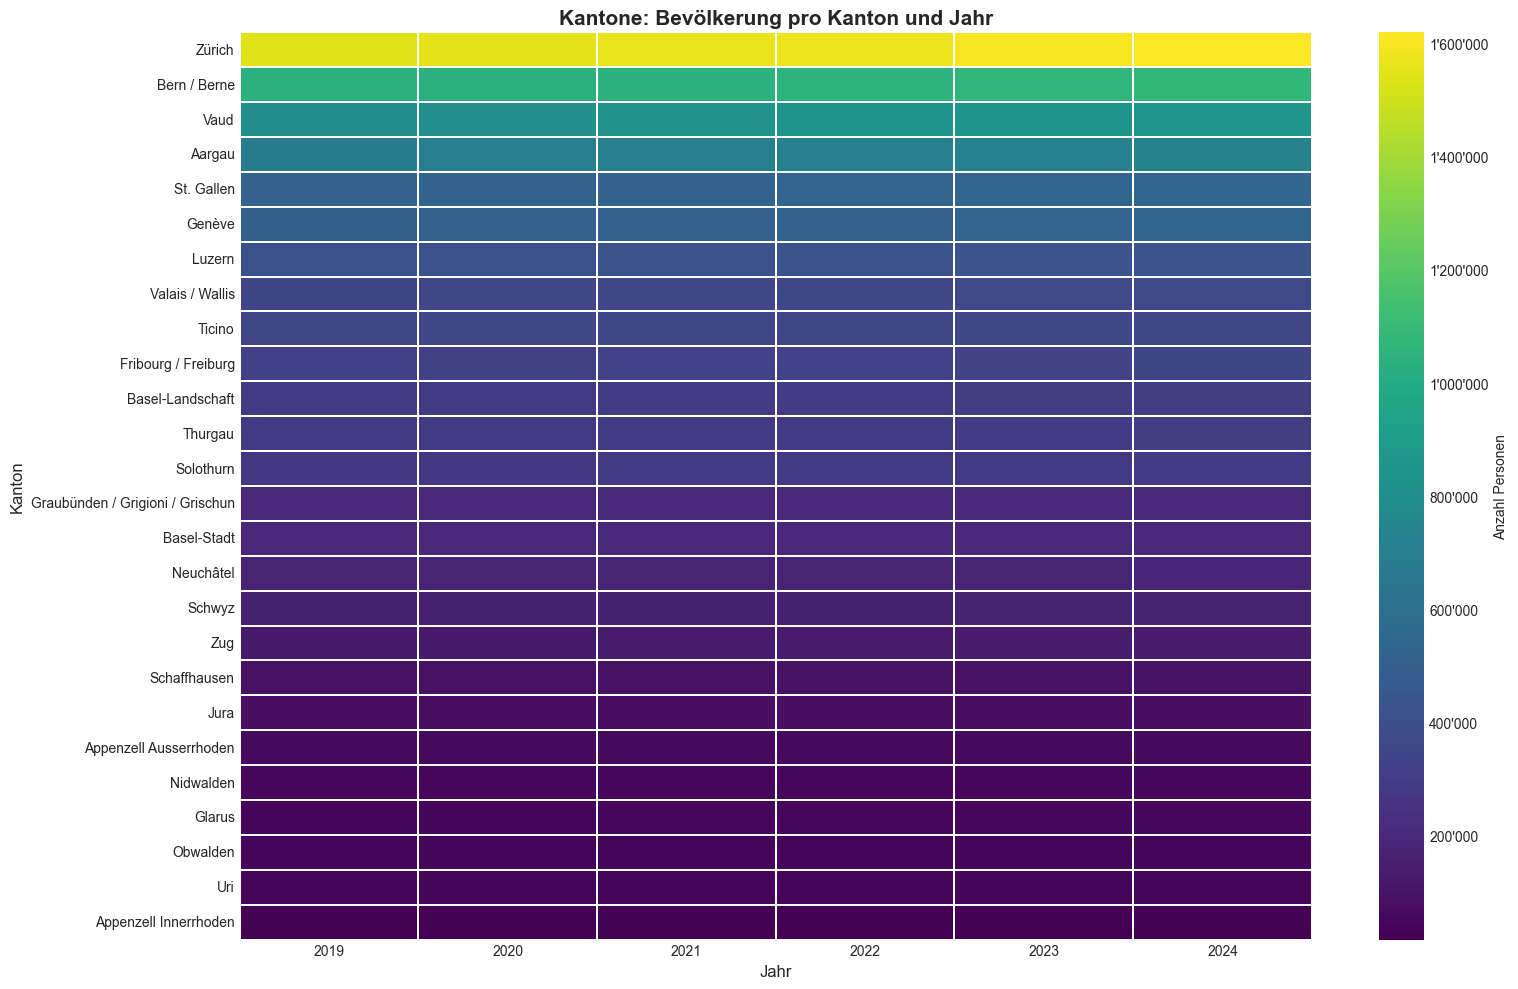

✓ Kanton/Jahr-Kombinationen: 156


In [229]:
# Demografische Bilanz: Kantone pro Jahr
print("\n" + "="*70)
print("DEMOGRAFISCHE BILANZ: KANTONE NACH JAHR")
print("="*70)

# Schweiz und fehlende Angaben auslassen, nur echte Kantone
kanton_year = demografische_gen[
    ~demografische_gen[canton_col].astype(str).str.strip().str.lower().isin(['schweiz', 'ohne angabe'])
].copy()

# Bevölkerung pro Kanton und Jahr aggregieren
kanton_year = (
    kanton_year.groupby([canton_col, 'year'], as_index=False)['population']
    .sum()
)

# Sortierung nach Gesamtbevölkerung für eine bessere Lesbarkeit
total_by_canton = (
    kanton_year.groupby(canton_col)['population']
    .sum()
    .sort_values(ascending=False)
)
kanton_order = total_by_canton.index.tolist()
heatmap_kanton = kanton_year.pivot(index=canton_col, columns='year', values='population').reindex(kanton_order)

plt.figure(figsize=(16, 10))
ax = sns.heatmap(
    heatmap_kanton,
    cmap='viridis',
    linewidths=0.2,
    linecolor='white',
    cbar_kws={'label': 'Anzahl Personen'},
)

ax.set_title('Kantone: Bevölkerung pro Kanton und Jahr', fontsize=15, fontweight='bold')
ax.set_xlabel('Jahr', fontsize=12)
ax.set_ylabel('Kanton', fontsize=12)
if ax.collections:
    colorbar = ax.collections[0].colorbar
    colorbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', "'")))
plt.tight_layout()
plt.show()

print(f"✓ Kanton/Jahr-Kombinationen: {kanton_year.shape[0]}")

## Überblick Wohneigentumsdaten

Diese Ausgabe liefert eine schnelle Qualitätskontrolle der Wohneigentumsdaten (Spalten, Datentypen, Missing Values).

Der Code dient der technischen Plausibilisierung vor der inhaltlichen Analyse und bereinigt dabei nicht benötigte Felder wie Status- oder Geo-Hilfsspalten.

In [230]:
# Datenübersicht und Explorative Statistiken
print("\n" + "="*70)
print("DATENÜBERSICHT: Wohneigentum-Daten (Kantonal)")
print("="*70)
print(f"\nDataset-Shape: {wohneigentum.shape[0]} Zeilen × {wohneigentum.shape[1]} Spalten")
print(f"\nVerfügbare Spalten:\n{list(wohneigentum.columns)}")
print(f"\nFehlende Werte:\n{wohneigentum.isnull().sum()[wohneigentum.isnull().sum() > 0]}")
print(f"\nDatentypen:\n{wohneigentum.dtypes}")

# Zeige Vorschau
print("\nVorschau (erste 5 Zeilen):")
# wohneigentum.head()

wohneigentum.drop(columns=['geo', 'obs_status'], errors='ignore', inplace=True)
wohneigentum.head()


DATENÜBERSICHT: Wohneigentum-Daten (Kantonal)

Dataset-Shape: 162 Zeilen × 10 Spalten

Verfügbare Spalten:
['time_period', 'geo', 'obs_value', 'obs_confidence', 'obs_status', 'code', 'label_en', 'label_fr', 'label_de', 'label_it']

Fehlende Werte:
Series([], dtype: int64)

Datentypen:
time_period         int64
geo                object
obs_value         float64
obs_confidence    float64
obs_status         object
code               object
label_en           object
label_fr           object
label_de           object
label_it           object
dtype: object

Vorschau (erste 5 Zeilen):


,time_period,obs_value,obs_confidence,code,label_en,label_fr,label_de,label_it
0,2019,27.7,0.5,CH040,Zürich,Zurich,Zürich,Zurigo
1,2019,38.8,0.6,CH021,Bern,Berne,Bern,Berna
2,2019,34.4,0.7,CH061,Luzern,Lucerne,Luzern,Lucerna
3,2019,42.9,3.5,CH062,Uri,Uri,Uri,Uri
4,2019,39.4,1.6,CH063,Schwyz,Schwyz,Schwyz,Svitto


## Detailcheck Bewohnertyp

Diese Zelle zeigt die Struktur der Bewohnertyp-Daten, um Kategorien und Kennzahlen korrekt zu verstehen.

Der Code gibt Datensatzgröße, Spaltennamen und fehlende Werte aus und unterstützt damit die Interpretation der späteren Generationenplots.

In [231]:
# Detaillierte Analyse der Bewohnertypen
print("\n" + "="*70)
print("BEWOHNERTYPEN-ANALYSE (BFS)")
print("="*70)
print(f"\nShape: {bewohnertyp.shape}")
print(f"\nSpalten: {list(bewohnertyp.columns)}")
print(f"\nFehlende Werte pro Spalte:")
print(bewohnertyp.isnull().sum())

print(f"\n📊 Beispieldaten:")
bewohnertyp.head()


BEWOHNERTYPEN-ANALYSE (BFS)

Shape: (340, 12)

Spalten: ['alter', 'bewohnertyp', 'absolute zahlen', 'vertrauens-intervall : \n± (in %)', 'anteil in %', 'vertrauens-\nintervall : \n± (in %-pkte)', 'datenqualität', 'sheet_type', 'time_period', 'age_num', 'birth_year', 'generation_label']

Fehlende Werte pro Spalte:
alter                                         0
bewohnertyp                                   0
absolute zahlen                               1
vertrauens-intervall : \n± (in %)             1
anteil in %                                   1
vertrauens-\nintervall : \n± (in %-pkte)     86
datenqualität                               321
sheet_type                                    0
time_period                                   0
age_num                                       0
birth_year                                    0
generation_label                              0
dtype: int64

📊 Beispieldaten:


,alter,bewohnertyp,absolute zahlen,vertrauens-intervall : \n± (in %),anteil in %,vertrauens-\nintervall : \n± (in %-pkte),datenqualität,sheet_type,time_period,age_num,birth_year,generation_label
0,15,Mieter oder Genossenschafter,40110.0,6.2,46.0,2.0,NaN,bewohnertyp,2024,15,2011,Generation Z (1997-2012)
1,15,Eigentümer,41551.0,5.6,47.7,2.0,NaN,bewohnertyp,2024,15,2011,Generation Z (1997-2012)
2,15,Andere Situation2),5534.0,17.1,6.3,1.0,NaN,bewohnertyp,2024,15,2011,Generation Z (1997-2012)
3,15,Total,87196.0,4.0,100.0,NaN,NaN,bewohnertyp,2024,15,2011,Generation Z (1997-2012)
4,16,Mieter oder Genossenschafter,41074.0,6.5,47.0,2.1,NaN,bewohnertyp,2024,16,2010,Generation Z (1997-2012)


## Detailcheck Wohnfläche

Diese Zelle prüft die Wohnflächen-Daten analog zum Bewohnertyp-Block.

Der Code macht sichtbar, welche Kennzahlen vorhanden sind und ob Datenlücken existieren, bevor Verteilungen nach Generation interpretiert werden.

In [232]:
# Detaillierte Analyse der Wohnflächenverteilung
print("\n" + "="*70)
print("WOHNFLÄCHENVERTEILUNG (BFS)")
print("="*70)
print(f"\nShape: {wohnflaeche.shape}")
print(f"\nSpalten: {list(wohnflaeche.columns)}")
print(f"\nFehlende Werte pro Spalte:")
print(wohnflaeche.isnull().sum())

print(f"\n📊 Beispieldaten:")
wohnflaeche.head()


WOHNFLÄCHENVERTEILUNG (BFS)

Shape: (100, 7)

Spalten: ['alter', 'wohnfläche (in m2) pro person', 'sheet_type', 'time_period', 'age_num', 'birth_year', 'generation_label']

Fehlende Werte pro Spalte:
alter                            0
wohnfläche (in m2) pro person    0
sheet_type                       0
time_period                      0
age_num                          0
birth_year                       0
generation_label                 0
dtype: int64

📊 Beispieldaten:


,alter,wohnfläche (in m2) pro person,sheet_type,time_period,age_num,birth_year,generation_label
0,0,27.6,wohnflaeche,2024,0,2026,Ausserhalb Definition
1,1,28.3,wohnflaeche,2024,1,2025,Ausserhalb Definition
2,2,28.2,wohnflaeche,2024,2,2024,Ausserhalb Definition
3,3,28.1,wohnflaeche,2024,3,2023,Ausserhalb Definition
4,4,27.9,wohnflaeche,2024,4,2022,Ausserhalb Definition


## Durchschnittliche Wohneigentumsquote nach Kanton

Diese Grafik vergleicht die mittlere Wohneigentumsquote zwischen den Kantonen.

Der Code aggregiert die Quote je Kanton (ohne Schweiz und ohne fehlende Angaben) und stellt die Werte als horizontales Balkendiagramm für einen direkten Rangvergleich dar.


WOHNEIGENTUM: DURCHSCHNITTLICHE QUOTE NACH KANTON


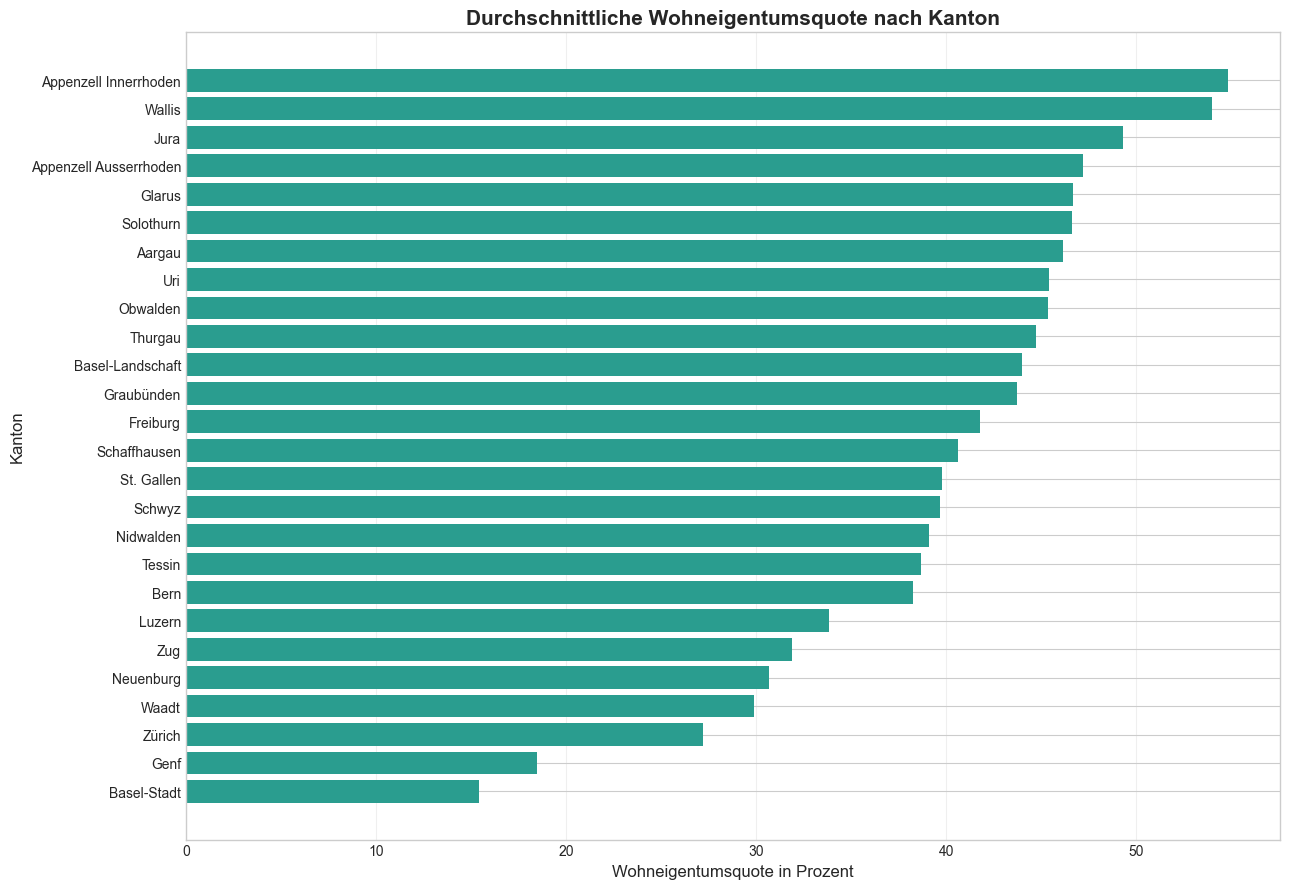

✓ Kantone dargestellt: 26


In [233]:
# Wohneigentum: durchschnittliche Quote nach Kanton
print("\n" + "="*70)
print("WOHNEIGENTUM: DURCHSCHNITTLICHE QUOTE NACH KANTON")
print("="*70)

required_cols = {'label_de', 'obs_value'}
if required_cols.issubset(set(wohneigentum.columns)):
    plot_data = (
        wohneigentum[['label_de', 'obs_value']]
        .dropna()
        .groupby('label_de', as_index=False)['obs_value']
        .mean()
        .query("label_de.str.lower() not in ['schweiz', 'ohne angabe']", engine='python')
        .sort_values('obs_value', ascending=True)
    )

    plt.figure(figsize=(13, 9))
    plt.barh(plot_data['label_de'].astype(str), plot_data['obs_value'], color='#2a9d8f')

    plt.title('Durchschnittliche Wohneigentumsquote nach Kanton', fontsize=15, fontweight='bold')
    plt.xlabel('Wohneigentumsquote in Prozent', fontsize=12)
    plt.ylabel('Kanton', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"✓ Kantone dargestellt: {plot_data.shape[0]}")
else:
    missing = required_cols - set(wohneigentum.columns)
    print(f"⚠️ Fehlende Spalten für Analyse: {missing}")

## Bewohnertyp nach Generation und Jahr

Diese Grafik zeigt, welcher Bewohnertyp innerhalb jeder Generation dominiert und wie hoch die jeweiligen Anteile sind.

Der Code berechnet pro Jahr und Generation relative Anteile (in Prozent) und visualisiert sie als gruppierte Balken mit Legende.


BEWOHNERTYP: ABSOLUTE ZAHLEN NACH GENERATION UND TYP (PRO JAHR)


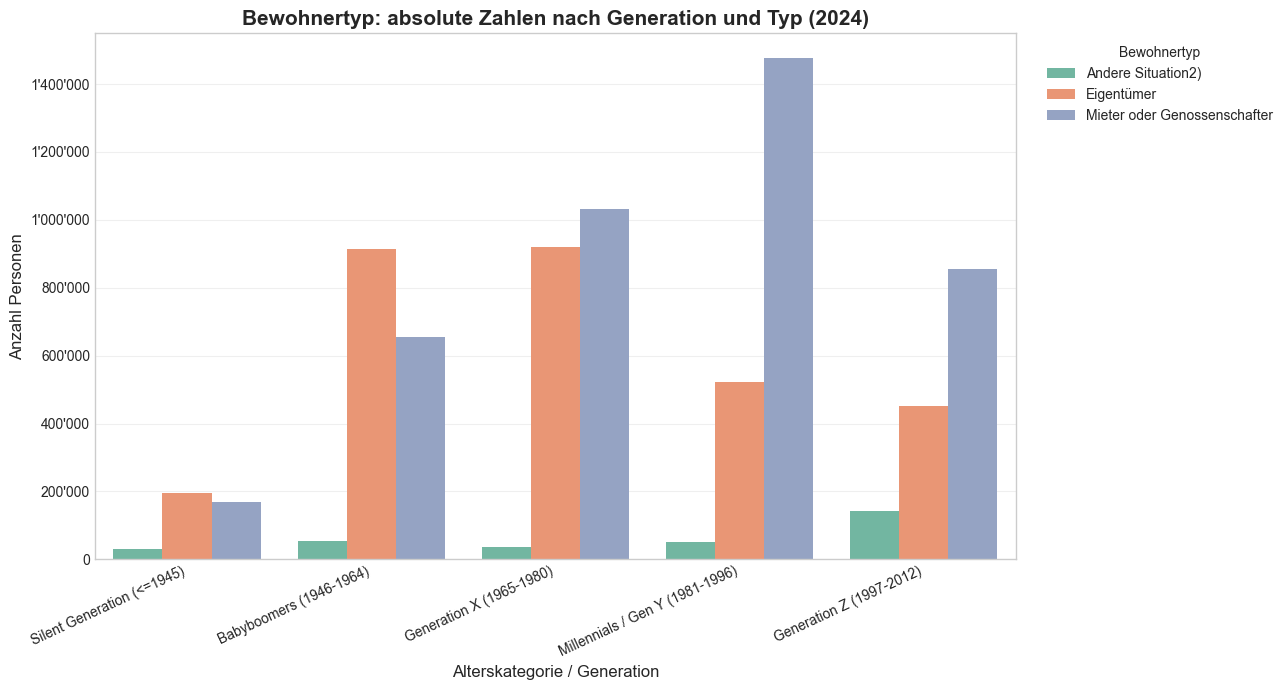

✓ Jahre dargestellt: 1
✓ Generationen dargestellt: 5
✓ Bewohnertypen in Legende: 3


In [234]:
# Bewohnertyp: absolute Zahlen nach Generation und Typ (pro Jahr)
print("\n" + "="*70)
print("BEWOHNERTYP: ABSOLUTE ZAHLEN NACH GENERATION UND TYP (PRO JAHR)")
print("="*70)

category_col = next((col for col in bewohnertyp.columns if col.lower() == 'bewohnertyp'), None)
value_col = next((col for col in bewohnertyp.columns if 'absolute' in col.lower() and 'zahl' in col.lower()), None)
year_col_bt = next((col for col in bewohnertyp.columns if 'time_period' in col.lower()), None)

if category_col is not None and value_col is not None and 'generation_label' in bewohnertyp.columns:
    base_data = bewohnertyp[[category_col, value_col, 'generation_label'] + ([year_col_bt] if year_col_bt else [])].dropna().copy()
    base_data = base_data[~base_data[category_col].astype(str).str.strip().str.lower().eq('total')].copy()
    base_data = base_data[base_data['generation_label'] != 'Ausserhalb Definition'].copy()

    if year_col_bt is not None:
        base_data['year_plot'] = pd.to_numeric(base_data[year_col_bt], errors='coerce')
        base_data = base_data[base_data['year_plot'].notna()].copy()
        base_data['year_plot'] = base_data['year_plot'].astype(int)
        years = sorted(base_data['year_plot'].unique().tolist())
    else:
        base_data['year_plot'] = 'Alle Jahre'
        years = ['Alle Jahre']

    plot_data = (
        base_data.groupby(['year_plot', 'generation_label', category_col], as_index=False, observed=True)[value_col]
        .sum()
        .sort_values(['year_plot', 'generation_label', category_col])
    )

    y_max = plot_data[value_col].max()

    for yr in years:
        year_data = plot_data[plot_data['year_plot'] == yr].copy()
        if hasattr(year_data['generation_label'], 'cat'):
            year_data['generation_label'] = year_data['generation_label'].cat.remove_unused_categories()

        plt.figure(figsize=(13, 7))
        ax = sns.barplot(
            data=year_data,
            x='generation_label',
            y=value_col,
            hue=category_col,
            palette='Set2'
        )

        ax.set_title(f'Bewohnertyp: absolute Zahlen nach Generation und Typ ({yr})', fontsize=15, fontweight='bold')
        ax.set_xlabel('Alterskategorie / Generation', fontsize=12)
        ax.set_ylabel('Anzahl Personen', fontsize=12)
        ax.set_ylim(0, y_max * 1.05)
        plt.xticks(rotation=25, ha='right')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', "'")))
        plt.legend(title='Bewohnertyp', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    print(f"✓ Jahre dargestellt: {len(years)}")
    print(f"✓ Generationen dargestellt: {plot_data['generation_label'].nunique()}")
    print(f"✓ Bewohnertypen in Legende: {plot_data[category_col].nunique()}")
else:
    print('⚠️ Für die Bewohnertyp-Visualisierung fehlen generation_label oder Kennzahl-Spalten.')

## Wohnfläche pro Person nach Generation und Jahr

Diese Grafik vergleicht die Verteilung der Wohnfläche pro Person zwischen Generationen.

Der Code erstellt pro Jahr einen eigenen Boxplot mit gleicher Achsenskalierung, damit Unterschiede in Lage und Streuung direkt vergleichbar sind.


WOHNFLÄCHE PRO PERSON NACH GENERATION (PRO JAHR)


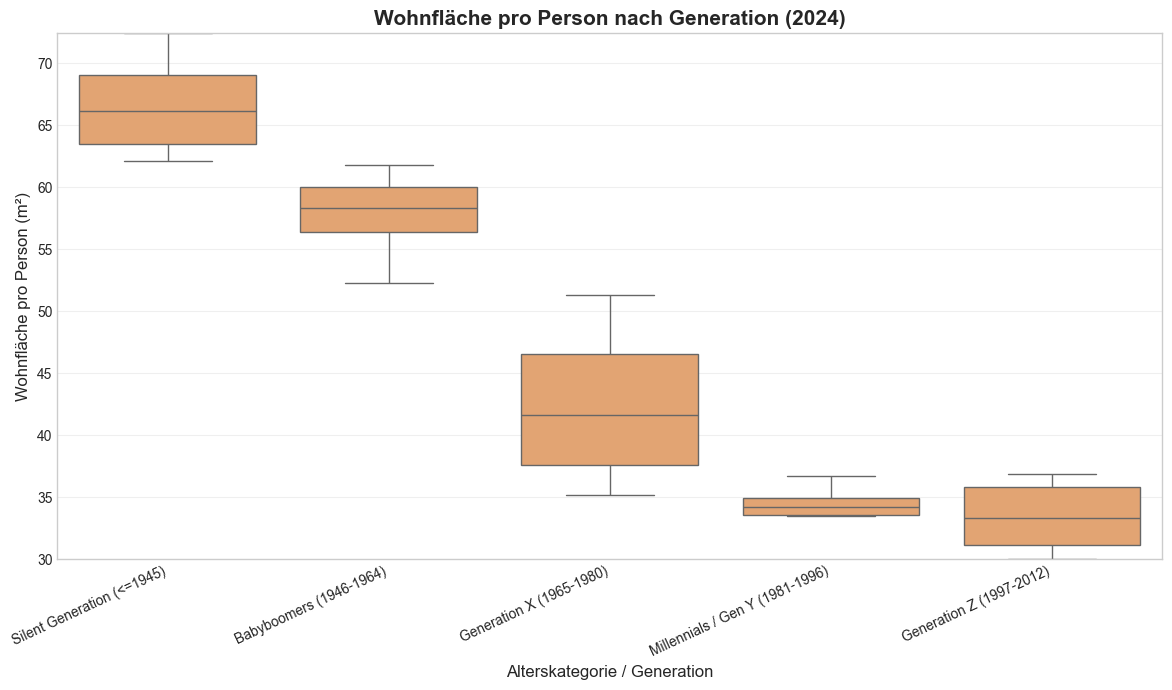

✓ Jahre dargestellt: 1
✓ Generationen dargestellt: 5


In [235]:
# Wohnfläche: Verteilung pro Generation (pro Jahr)
print("\n" + "="*70)
print("WOHNFLÄCHE PRO PERSON NACH GENERATION (PRO JAHR)")
print("="*70)

room_col = next((col for col in wohnflaeche.columns if 'wohnfläche' in col.lower() and 'person' in col.lower()), None)
year_col_wf = next((col for col in wohnflaeche.columns if 'time_period' in col.lower()), None)
if room_col is None:
    numeric_cols = wohnflaeche.select_dtypes(include=[np.number]).columns.tolist()
    room_col = numeric_cols[0] if numeric_cols else None

if room_col is not None and 'generation_label' in wohnflaeche.columns:
    base_data = wohnflaeche[[room_col, 'generation_label'] + ([year_col_wf] if year_col_wf else [])].dropna().copy()
    base_data = base_data[base_data['generation_label'] != 'Ausserhalb Definition'].copy()

    if year_col_wf is not None:
        base_data['year_plot'] = pd.to_numeric(base_data[year_col_wf], errors='coerce')
        base_data = base_data[base_data['year_plot'].notna()].copy()
        base_data['year_plot'] = base_data['year_plot'].astype(int)
        years = sorted(base_data['year_plot'].unique().tolist())
    else:
        base_data['year_plot'] = 'Alle Jahre'
        years = ['Alle Jahre']

    y_min = base_data[room_col].min()
    y_max = base_data[room_col].max()

    for yr in years:
        plot_data = base_data[base_data['year_plot'] == yr].copy()
        if hasattr(plot_data['generation_label'], 'cat'):
            plot_data['generation_label'] = plot_data['generation_label'].cat.remove_unused_categories()

        plt.figure(figsize=(12, 7))
        sns.boxplot(data=plot_data, x='generation_label', y=room_col, color='#f4a261')

        plt.title(f'Wohnfläche pro Person nach Generation ({yr})', fontsize=15, fontweight='bold')
        plt.xlabel('Alterskategorie / Generation', fontsize=12)
        plt.ylabel('Wohnfläche pro Person (m²)', fontsize=12)
        plt.ylim(y_min, y_max)
        plt.xticks(rotation=25, ha='right')
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    print(f"✓ Jahre dargestellt: {len(years)}")
    print(f"✓ Generationen dargestellt: {base_data['generation_label'].nunique()}")
else:
    print('⚠️ Keine geeignete Wohnflächen-Spalte oder generation_label gefunden.')

## Verknüpfung: Generation, Jahr, Wohnform und Wohnfläche

Diese Analyse kombiniert die drei Quellen auf Ebene Jahr und Generation, um Beziehungen zwischen Bevölkerungsanteil, dominanter Wohnform und Wohnfläche sichtbar zu machen.

Der Code baut eine gemeinsame Tabelle, prüft die Datenabdeckung, erstellt bei ausreichender Basis eine Korrelationsmatrix und gibt Story-Insights aus.


VERKNUEPFTE ANALYSE: GENERATION, JAHR, WOHNFLAECHE UND BEWOHNERTYP
✓ Gemeinsame Generation/Jahr-Tabelle: (30, 12)
 year                generation_label  population  avg_age  population_share_pct  Andere Situation2)  Eigentümer  Mieter oder Genossenschafter dominant_bewohnertyp  dominant_bewohnertyp_share_pct  mean_wohnflaeche  median_wohnflaeche
 2019      Silent Generation (<=1945)     1700920     86.5             10.639021                 NaN         NaN                           NaN                  NaN                             NaN               NaN                 NaN
 2019         Babyboomers (1946-1964)     3805414     64.0             23.802341                 NaN         NaN                           NaN                  NaN                             NaN               NaN                 NaN
 2019        Generation X (1965-1980)     3969020     46.5             24.825674                 NaN         NaN                           NaN                  NaN                    

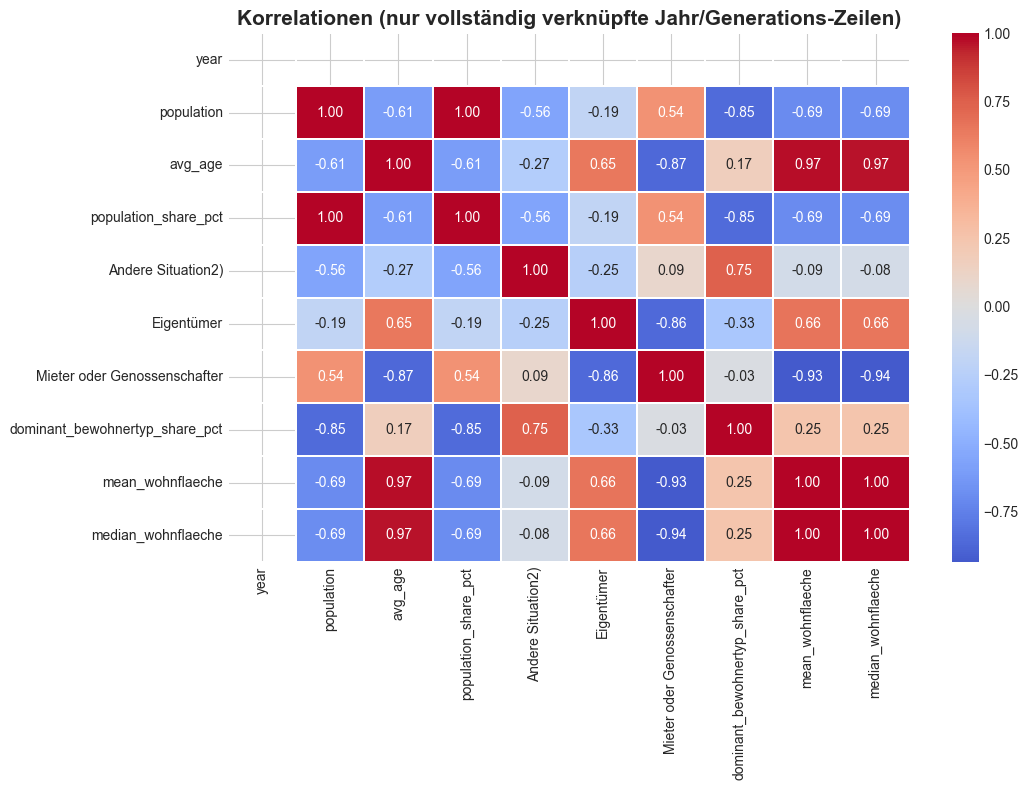


Hinweis zur Interpretierbarkeit:
  - Bewohnertyp und Wohnfläche enthalten aktuell nur ein Jahr (2024).
  - Deshalb ist eine echte Trendanalyse dieser beiden Quellen über mehrere Jahre nicht möglich.
  - Der Merge funktioniert, aber für 2019-2023 bleiben die BFS-Komponenten leer (NaN).
  - Für eine vollwertige Zeitreihen-Story brauchst du BFS-Daten für weitere Jahre.

Key Insight (nur vollständig verfügbare Kombinationen):
  2024: Millennials / Gen Y (1981-1996) ist die stärkste Gruppe (25.9%), dominanter Bewohnertyp: Mieter oder Genossenschafter (5.2%), Ø Wohnfläche: 34.5 m²


In [236]:
# Verknüpfte Analyse: Generation, Jahr, Wohnfläche und Bewohnertyp
# Fragestellung: Wie hängen Generation, Wohnform und Wohnfläche gemeinsam zusammen?
# Hypothese: Ältere Generationen verfügen im Schnitt über mehr Wohnfläche und unterscheiden sich in ihrer Wohnform.
print("\n" + "="*70)
print("VERKNUEPFTE ANALYSE: GENERATION, JAHR, WOHNFLAECHE UND BEWOHNERTYP")
print("="*70)

# 1) Demografie (Referenz: mehrere Jahre)
combined_gen_year = (
    demografische_gen[
        demografische_gen['generation_label'] != 'Ausserhalb Definition'
    ]
    .groupby(['year', 'generation_label'], as_index=False, observed=True)
    .agg(
        population=('population', 'sum'),
        avg_age=('age_num', 'mean')
    )
)
combined_gen_year['population_share_pct'] = combined_gen_year.groupby('year')['population'].transform(lambda s: s / s.sum() * 100)

# 2) Bewohnertyp-Anteile pro Generation und Jahr
category_col = next((col for col in bewohnertyp.columns if col.lower() == 'bewohnertyp'), None)
value_col = next((col for col in bewohnertyp.columns if 'absolute' in col.lower() and 'zahl' in col.lower()), None)
year_col_bt = next((col for col in bewohnertyp.columns if 'time_period' in col.lower() or 'jahr' in col.lower()), None)

if category_col is not None and value_col is not None and 'generation_label' in bewohnertyp.columns and year_col_bt is not None:
    bt_base = bewohnertyp[[category_col, value_col, 'generation_label', year_col_bt]].dropna().copy()
    bt_base = bt_base[~bt_base[category_col].astype(str).str.strip().str.lower().eq('total')].copy()
    bt_base = bt_base[bt_base['generation_label'] != 'Ausserhalb Definition'].copy()
    bt_base['year'] = pd.to_numeric(bt_base[year_col_bt], errors='coerce')
    bt_base[value_col] = pd.to_numeric(bt_base[value_col], errors='coerce')
    bt_base = bt_base[bt_base['year'].notna() & bt_base[value_col].notna()].copy()
    bt_base['year'] = bt_base['year'].astype(int)

    bt_totals = bt_base.groupby(['year', 'generation_label'], as_index=False, observed=True)[value_col].sum()
    bt_share = bt_base.merge(bt_totals, on=['year', 'generation_label'], suffixes=('', '_total'))
    bt_share['share_pct'] = bt_share[value_col] / bt_share[f'{value_col}_total'] * 100

    bt_share_wide = (
        bt_share.pivot_table(
            index=['year', 'generation_label'],
            columns=category_col,
            values='share_pct',
            fill_value=0,
            aggfunc='mean'
        )
        .reset_index()
    )

    # Dominanter Bewohnertyp pro Jahr/Generation als leicht lesbares Story-Feature
    bt_dominant = (
        bt_share.sort_values(['year', 'generation_label', 'share_pct'], ascending=[True, True, False])
        .groupby(['year', 'generation_label'], as_index=False)
        .first()[['year', 'generation_label', category_col, 'share_pct']]
        .rename(columns={category_col: 'dominant_bewohnertyp', 'share_pct': 'dominant_bewohnertyp_share_pct'})
    )
else:
    bt_share_wide = pd.DataFrame()
    bt_dominant = pd.DataFrame()

# 3) Wohnfläche pro Generation und Jahr
room_col = next((col for col in wohnflaeche.columns if 'wohnfläche' in col.lower() and 'person' in col.lower()), None)
year_col_wf = next((col for col in wohnflaeche.columns if 'time_period' in col.lower() or 'jahr' in col.lower()), None)
if room_col is None:
    numeric_cols = wohnflaeche.select_dtypes(include=[np.number]).columns.tolist()
    room_col = numeric_cols[0] if numeric_cols else None

if room_col is not None and 'generation_label' in wohnflaeche.columns and year_col_wf is not None:
    wf_base = wohnflaeche[[room_col, 'generation_label', year_col_wf]].dropna().copy()
    wf_base = wf_base[wf_base['generation_label'] != 'Ausserhalb Definition'].copy()
    wf_base['year'] = pd.to_numeric(wf_base[year_col_wf], errors='coerce')
    wf_base[room_col] = pd.to_numeric(wf_base[room_col], errors='coerce')
    wf_base = wf_base[wf_base['year'].notna() & wf_base[room_col].notna()].copy()
    wf_base['year'] = wf_base['year'].astype(int)

    wf_summary = (
        wf_base.groupby(['year', 'generation_label'], as_index=False, observed=True)
        .agg(
            mean_wohnflaeche=(room_col, 'mean'),
            median_wohnflaeche=(room_col, 'median')
        )
    )
else:
    wf_summary = pd.DataFrame()

# 4) Gemeinsame Verknüpfung über Jahr + Generation
combined_generation = combined_gen_year.copy()
if not bt_share_wide.empty:
    combined_generation = combined_generation.merge(bt_share_wide, on=['year', 'generation_label'], how='left')
if not bt_dominant.empty:
    combined_generation = combined_generation.merge(bt_dominant, on=['year', 'generation_label'], how='left')
if not wf_summary.empty:
    combined_generation = combined_generation.merge(wf_summary, on=['year', 'generation_label'], how='left')

combined_generation = combined_generation.sort_values(['year', 'generation_label'])

print(f"✓ Gemeinsame Generation/Jahr-Tabelle: {combined_generation.shape}")
print(combined_generation.head(10).to_string(index=False))

# 5) Datenabdeckung transparent machen
years_demo = sorted(combined_gen_year['year'].unique().tolist())
years_bt = sorted(bt_share_wide['year'].unique().tolist()) if not bt_share_wide.empty else []
years_wf = sorted(wf_summary['year'].unique().tolist()) if not wf_summary.empty else []

print("\nDatenabdeckung:")
print(f"  - Demografie Jahre: {years_demo}")
print(f"  - Bewohnertyp Jahre: {years_bt if years_bt else 'keine'}")
print(f"  - Wohnfläche Jahre: {years_wf if years_wf else 'keine'}")

complete_mask = combined_generation[['mean_wohnflaeche', 'dominant_bewohnertyp_share_pct']].notna().all(axis=1) if {'mean_wohnflaeche', 'dominant_bewohnertyp_share_pct'}.issubset(combined_generation.columns) else pd.Series(False, index=combined_generation.index)
complete_rows = int(complete_mask.sum())
print(f"  - Vollständig verknüpfte Zeilen (inkl. Wohnfläche + Bewohnertyp): {complete_rows} von {combined_generation.shape[0]}")

# 6) Korrelationen nur auf sinnvoller Datengrundlage
numeric_cols = combined_generation.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1 and complete_rows >= 5:
    corr_df = combined_generation.loc[complete_mask, numeric_cols].copy()
    corr = corr_df.corr()
    plt.figure(figsize=(11, 8))
    ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.3)
    ax.set_title('Korrelationen (nur vollständig verknüpfte Jahr/Generations-Zeilen)', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 7) Erklärung bei Datenlimitierungen
if len(years_bt) <= 1 and len(years_wf) <= 1:
    print("\nHinweis zur Interpretierbarkeit:")
    print("  - Bewohnertyp und Wohnfläche enthalten aktuell nur ein Jahr (2024).")
    print("  - Deshalb ist eine echte Trendanalyse dieser beiden Quellen über mehrere Jahre nicht möglich.")
    print("  - Der Merge funktioniert, aber für 2019-2023 bleiben die BFS-Komponenten leer (NaN).")
    print("  - Für eine vollwertige Zeitreihen-Story brauchst du BFS-Daten für weitere Jahre.")

# 8) Key Insight für Storytelling
if {'dominant_bewohnertyp', 'dominant_bewohnertyp_share_pct', 'mean_wohnflaeche'}.issubset(combined_generation.columns):
    insight_table = combined_generation.dropna(subset=['dominant_bewohnertyp', 'mean_wohnflaeche']).copy()
    if not insight_table.empty:
        print('\nKey Insight (nur vollständig verfügbare Kombinationen):')
        for yr in sorted(insight_table['year'].unique().tolist()):
            top_row = (
                insight_table[insight_table['year'] == yr]
                .sort_values('population_share_pct', ascending=False)
                .iloc[0]
            )
            print(
                f"  {yr}: {top_row['generation_label']} ist die stärkste Gruppe ({top_row['population_share_pct']:.1f}%), "
                f"dominanter Bewohnertyp: {top_row['dominant_bewohnertyp']} ({top_row['dominant_bewohnertyp_share_pct']:.1f}%), "
                f"Ø Wohnfläche: {top_row['mean_wohnflaeche']:.1f} m²"
            )

## Verknüpfung: Eigentumsquote und Altersstruktur

Diese Analyse prüft den Zusammenhang zwischen Eigentumsquote und Altersstruktur auf Kantonsebene über die Zeit.

Im Code werden Kantonsnamen harmonisiert, Datensätze gemerged und anschließend Korrelation, Regressionsplot und Zeitvergleich erzeugt.


VERKNUEPFTE ANALYSE: EIGENTUMSQUOTE UND ALTERSSTRUKTUR
✓ Verknüpfte Kanton/Jahr-Tabelle: (0, 6)
Empty DataFrame
Columns: [canton_key, year, population, avg_age, share_65_plus, ownership_rate]
Index: []


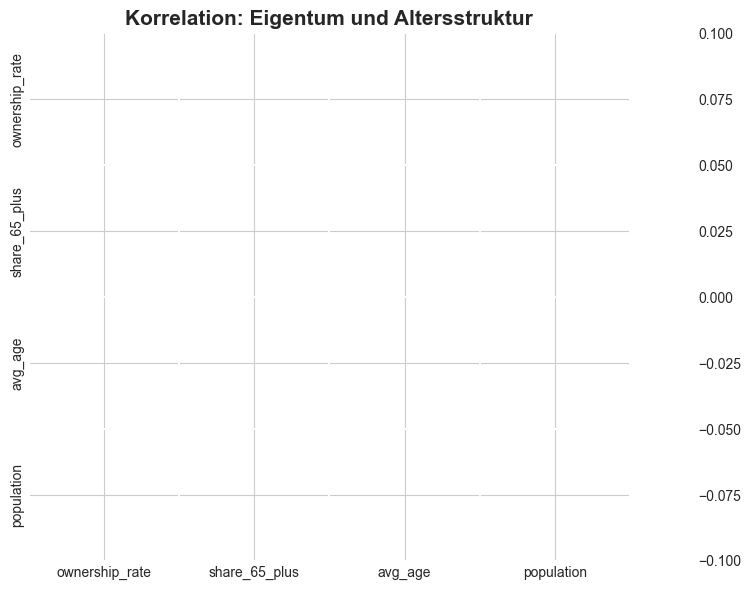

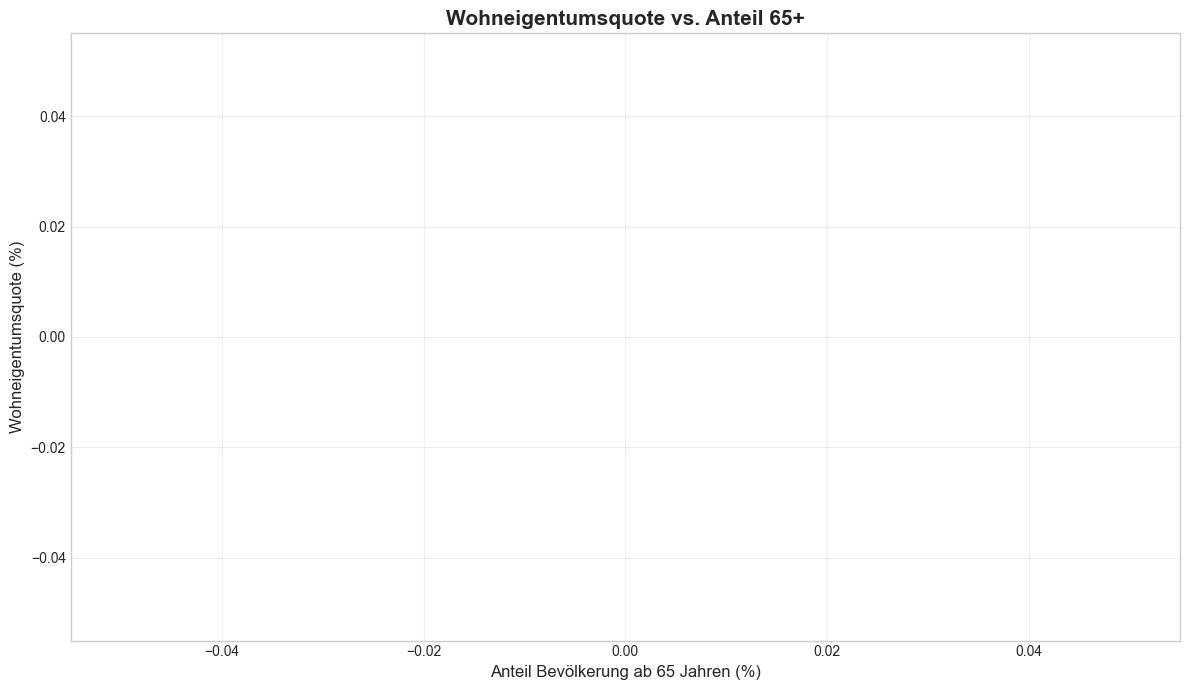

✓ Korrelation Eigentumsquote vs. Anteil 65+: nan


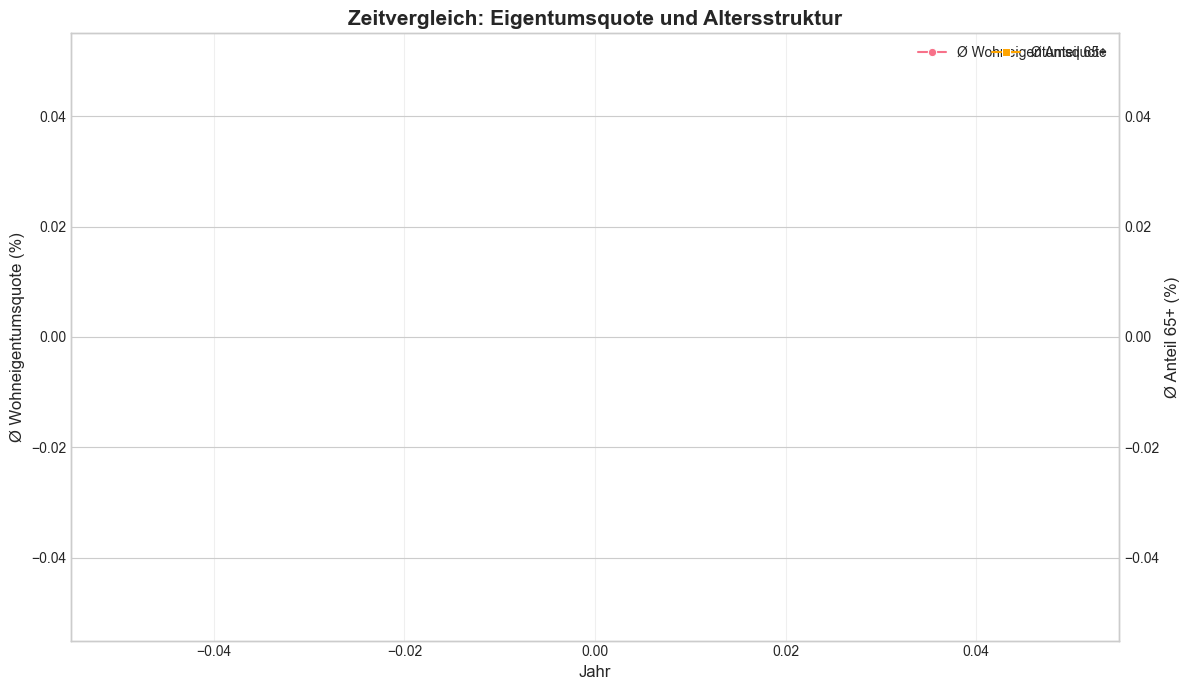


Kurzinsights:
  - Die Grafik verbindet erstmals Eigentumsquote mit Altersstruktur auf Kanton/Jahr-Ebene.
  - Die Zeitreihe zeigt, wie sich beide Kennzahlen parallel über die Jahre entwickeln.


In [237]:
# Verknüpfte Analyse: Eigentumsquote, Kanton und Altersstruktur
# Fragestellung: Ist die Eigentumsquote in Kantonen mit älterer Bevölkerung höher?
# Hypothese: Kantone mit höherem Anteil älterer Personen weisen höhere Wohneigentumsquoten auf.
print("\n" + "="*70)
print("VERKNUEPFTE ANALYSE: EIGENTUMSQUOTE UND ALTERSSTRUKTUR")
print("="*70)

# Diese Analyse lädt die Quellen nochmals direkt, damit der Join unabhängig vom Notebook-Zustand reproduzierbar bleibt.
ownership_df = pd.read_csv(WHONEIGENTUMSQUOTE_PROCESSED_PATH)
demo_df = pd.read_csv(DEMOGRAFISCHE_BILANZ_PATH, sep=';', encoding='latin1')


def canton_to_german_label(value):
    text = str(value).strip()
    if '/' in text:
        text = text.split('/')[0].strip()
    translation = {
        'Bern': 'Bern',
        'Fribourg': 'Freiburg',
        'Genève': 'Genf',
        'Neuchâtel': 'Neuenburg',
        'Ticino': 'Tessin',
        'Vaud': 'Waadt',
        'Valais': 'Wallis',
        'Schweiz': 'Schweiz',
        'Ohne Angabe': 'Ohne Angabe',
    }
    return translation.get(text, text)


# Eigentumsdaten auf Kanton/Jahr bringen
ownership_year_col = next((c for c in ownership_df.columns if 'time_period' in c.lower() or 'jahr' in c.lower() or 'year' in c.lower()), None)
ownership_canton_col = next((c for c in ownership_df.columns if c.lower() in ['label_de', 'kanton', 'geo', 'code']), None)
ownership_value_col = next((c for c in ownership_df.columns if 'obs_value' in c.lower() or 'value' in c.lower()), None)

# Demografie auf Kanton/Jahr bringen
demo_kanton_col = next((c for c in demo_df.columns if 'kanton' in c.lower()), None)
demo_year_col = next((c for c in demo_df.columns if 'jahr' in c.lower()), None)
demo_age_col = next((c for c in demo_df.columns if 'alter' in c.lower()), None)
demo_pop_col = next((c for c in demo_df.columns if '31' in c.lower() and 'dez' in c.lower()), None)

if any(v is None for v in [ownership_year_col, ownership_canton_col, ownership_value_col, demo_kanton_col, demo_year_col, demo_age_col, demo_pop_col]):
    print('⚠️ Eigentums- oder Demografie-Spalten konnten nicht eindeutig bestimmt werden.')
else:
    ownership = ownership_df[[ownership_canton_col, ownership_year_col, ownership_value_col]].dropna().copy()
    ownership[ownership_year_col] = pd.to_numeric(ownership[ownership_year_col], errors='coerce')
    ownership[ownership_value_col] = pd.to_numeric(ownership[ownership_value_col], errors='coerce')
    ownership = ownership[ownership[ownership_year_col].notna() & ownership[ownership_value_col].notna()].copy()
    ownership[ownership_year_col] = ownership[ownership_year_col].astype(int)
    ownership['canton_key'] = ownership[ownership_canton_col].map(canton_to_german_label)
    ownership = (
        ownership.groupby(['canton_key', ownership_year_col], as_index=False)[ownership_value_col]
        .mean()
        .rename(columns={ownership_year_col: 'year', ownership_value_col: 'ownership_rate'})
    )

    demo_df = demo_df.copy()
    demo_df[demo_year_col] = pd.to_numeric(demo_df[demo_year_col], errors='coerce')
    demo_df[demo_pop_col] = pd.to_numeric(demo_df[demo_pop_col], errors='coerce')
    demo_df['age_num'] = pd.to_numeric(demo_df[demo_age_col].astype(str).str.extract(r'(\d+)', expand=False), errors='coerce')
    demo_df = demo_df[demo_df[demo_year_col].notna() & demo_df[demo_pop_col].notna() & demo_df['age_num'].notna()].copy()
    demo_df[demo_year_col] = demo_df[demo_year_col].astype(int)
    demo_df['is_65_plus'] = demo_df['age_num'] >= 65
    demo_df['canton_key'] = demo_df[demo_kanton_col].map(canton_to_german_label)
    demo_df = demo_df.rename(columns={demo_year_col: 'year'})

    demo_canton_year = (
        demo_df.groupby(['canton_key', 'year'], as_index=False)
        .agg(
            population=(demo_pop_col, 'sum'),
            avg_age=('age_num', 'mean'),
            share_65_plus=('is_65_plus', 'mean')
        )
    )
    demo_canton_year['share_65_plus'] = demo_canton_year['share_65_plus'] * 100

    merged_canton_year = demo_canton_year.merge(
        ownership,
        on=['canton_key', 'year'],
        how='inner'
    )

    print(f"✓ Verknüpfte Kanton/Jahr-Tabelle: {merged_canton_year.shape}")
    print(merged_canton_year.head(10).to_string(index=False))

    corr_cols = ['ownership_rate', 'share_65_plus', 'avg_age', 'population']
    corr = merged_canton_year[corr_cols].corr()
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.3)
    ax.set_title('Korrelation: Eigentum und Altersstruktur', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 7))
    ax = sns.regplot(
        data=merged_canton_year,
        x='share_65_plus',
        y='ownership_rate',
        scatter_kws={'alpha': 0.65},
        line_kws={'color': 'red'}
    )
    ax.set_title('Wohneigentumsquote vs. Anteil 65+', fontsize=15, fontweight='bold')
    ax.set_xlabel('Anteil Bevölkerung ab 65 Jahren (%)', fontsize=12)
    ax.set_ylabel('Wohneigentumsquote (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    ownership_corr = merged_canton_year['ownership_rate'].corr(merged_canton_year['share_65_plus'])
    print(f"✓ Korrelation Eigentumsquote vs. Anteil 65+: {ownership_corr:.3f}")

    top_years = (
        merged_canton_year.groupby('year', as_index=False)
        .agg(ownership_rate=('ownership_rate', 'mean'), share_65_plus=('share_65_plus', 'mean'))
        .sort_values('year')
    )
    plt.figure(figsize=(12, 7))
    ax = sns.lineplot(data=top_years, x='year', y='ownership_rate', marker='o', label='Ø Wohneigentumsquote')
    ax2 = ax.twinx()
    sns.lineplot(data=top_years, x='year', y='share_65_plus', marker='s', color='orange', label='Ø Anteil 65+', ax=ax2)
    ax.set_title('Zeitvergleich: Eigentumsquote und Altersstruktur', fontsize=15, fontweight='bold')
    ax.set_xlabel('Jahr', fontsize=12)
    ax.set_ylabel('Ø Wohneigentumsquote (%)', fontsize=12)
    ax2.set_ylabel('Ø Anteil 65+ (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('\nKurzinsights:')
    if pd.notna(ownership_corr):
        print(f"  - Die Korrelation zwischen Eigentumsquote und Anteil 65+ liegt bei {ownership_corr:.2f}.")
    print('  - Die Grafik verbindet erstmals Eigentumsquote mit Altersstruktur auf Kanton/Jahr-Ebene.')
    print('  - Die Zeitreihe zeigt, wie sich beide Kennzahlen parallel über die Jahre entwickeln.')

## Abschließende Zusammenfassung

Diese letzte Zelle fasst die wichtigsten deskriptiven Kennzahlen aller verwendeten Datensätze kompakt zusammen.

Der Code liefert eine schnelle Management-Übersicht und gibt mögliche nächste Analyseschritte für Storytelling und Dashboarding aus.

In [238]:
# Abschließende statistische Zusammenfassung und Erkenntnisse
print("\n" + "="*70)
print("STATISTISCHE ZUSAMMENFASSUNG - ALLE DATENSÄTZE")
print("="*70)

# 1. Wohneigentum Statistiken
print("\n📊 WOHNEIGENTUMSQUOTEN (Kantonal):")
print(f"   Anzahl Kantone: {wohneigentum.shape[0]}")
numeric_cols_we = wohneigentum.select_dtypes(include=[np.number]).columns
if len(numeric_cols_we) > 0:
    we_col = numeric_cols_we[0]
    print(f"   Spalte analysiert: {we_col}")
    print(f"   Min: {wohneigentum[we_col].min():.2f}")
    print(f"   Max: {wohneigentum[we_col].max():.2f}")
    print(f"   Mittelwert: {wohneigentum[we_col].mean():.2f}")
    print(f"   Median: {wohneigentum[we_col].median():.2f}")
    print(f"   Standardabweichung: {wohneigentum[we_col].std():.2f}")

# 2. Bewohnertypen Statistiken
print("\n👥 BEWOHNERTYPEN (BFS):")
print(f"   Datensatz-Größe: {bewohnertyp.shape}")
numeric_cols_bt = bewohnertyp.select_dtypes(include=[np.number]).columns
if len(numeric_cols_bt) > 0:
    print(f"   Numerische Spalten: {list(numeric_cols_bt)}")
    for col in numeric_cols_bt[:3]:  # Zeige max 3 Spalten
        print(f"   ├─ {col}:")
        print(f"      Mean: {bewohnertyp[col].mean():.2f}, Std: {bewohnertyp[col].std():.2f}")

# 3. Wohnflächenverteilung Statistiken
print("\n🏠 WOHNFLÄCHENVERTEILUNG (BFS):")
print(f"   Datensatz-Größe: {wohnflaeche.shape}")
numeric_cols_wf = wohnflaeche.select_dtypes(include=[np.number]).columns
if len(numeric_cols_wf) > 0:
    print(f"   Numerische Spalten: {list(numeric_cols_wf)}")
    for col in numeric_cols_wf[:3]:  # Zeige max 3 Spalten
        print(f"   ├─ {col}:")
        print(f"      Mean: {wohnflaeche[col].mean():.2f}, Std: {wohnflaeche[col].std():.2f}")

# 4. Demografische Bilanz Statistiken
print("\n👤 DEMOGRAFISCHE BILANZ:")
print(f"   Datensatz-Größe: {demografische_bilanz.shape}")
if 'year' in demografische_gen.columns:
    print(f"   Abgedeckte Jahre: {demografische_gen['year'].min()} bis {demografische_gen['year'].max()}")
if 'generation_label' in demografische_gen.columns:
    print(f"   Generationen: {demografische_gen['generation_label'].nunique()}")
if 'population' in demografische_gen.columns:
    print(f"   Gesamtbevölkerung (Summe über alle Zeilen): {int(demografische_gen['population'].sum()):,}".replace(',', "'"))

# 5. Gesamtzusammenfassung
print("\n" + "="*70)
print("✓ EDA abgeschlossen!")
print("="*70)
print("\nAnzahl Datensätze insgesamt:")
print(f"  • Wohneigentum: {wohneigentum.shape[0]} Kantone")
print(f"  • Bewohnertypen: {bewohnertyp.shape[0]} Einträge")
print(f"  • Wohnflächen: {wohnflaeche.shape[0]} Einträge")
print(f"  • Demografische Bilanz: {demografische_bilanz.shape[0]} Einträge")



STATISTISCHE ZUSAMMENFASSUNG - ALLE DATENSÄTZE

📊 WOHNEIGENTUMSQUOTEN (Kantonal):
   Anzahl Kantone: 162
   Spalte analysiert: time_period
   Min: 2019.00
   Max: 2024.00
   Mittelwert: 2021.50
   Median: 2021.50
   Standardabweichung: 1.71

👥 BEWOHNERTYPEN (BFS):
   Datensatz-Größe: (340, 12)
   Numerische Spalten: ['alter', 'absolute zahlen', 'vertrauens-intervall : \n± (in %)', 'anteil in %', 'vertrauens-\nintervall : \n± (in %-pkte)', 'time_period', 'age_num', 'birth_year']
   ├─ alter:
      Mean: 57.00, Std: 24.57
   ├─ absolute zahlen:
      Mean: 44288.33, Std: 41082.27
   ├─ vertrauens-intervall : 
± (in %):
      Mean: 11.99, Std: 12.22

🏠 WOHNFLÄCHENVERTEILUNG (BFS):
   Datensatz-Größe: (100, 7)
   Numerische Spalten: ['alter', 'wohnfläche (in m2) pro person', 'time_period', 'age_num', 'birth_year']
   ├─ alter:
      Mean: 49.50, Std: 29.01
   ├─ wohnfläche (in m2) pro person:
      Mean: 45.22, Std: 14.37
   ├─ time_period:
      Mean: 2024.00, Std: 0.00

👤 DEMOGRAFISCHE 